# 01 - Data preparation

Download the dataset, check it for broken files, duplicates and wrong labels, and make the train / validation / test split that every model uses.

Dataset: [Spoiled and Fresh Fruit Inspection Dataset](https://data.mendeley.com/datasets/6ps7gtp2wg/1) (Pachon Suescun et al., 2020, CC BY 4.0). 8 fruits (banana, lemon, lulo, mango, orange, strawberry, tamarillo, tomato), each fresh and spoiled, 1,000 RGB images of 224 x 224 per class. Folder names are `F_<Fruit>` (fresh) and `S_<Fruit>` (spoiled).

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(".."))

import shutil, urllib.request, zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

from src import data_audit as da
from src.config import (COMBINED_NAMES, DATASET_DIR, DATASET_ZIP_URL, FIGURES_DIR, FRUITS, IMG_SIZE,
                        METADATA_CSV, PROJECT_ROOT, RAW_DIR, REPORTS_DIR, SEED, SPLITS_DIR)
%matplotlib inline

Settings for the cleaning and the split. They are explained in sections 2 and 3.

In [2]:
SPLITS = ["train", "val", "test"]
SPLIT_RATIOS = {"train": 0.70, "val": 0.15, "test": 0.15}

BLOCK_SIZE = 25        # 25 ảnh liên tiếp của một thư mục luôn nằm cùng một tập
NEAR_DUP_PHASH = 6     # ảnh gần trùng: khoảng cách pHash <= 6 ...
NEAR_DUP_THUMB = 0.03  # ... và thumbnail 16x16 gần giống nhau ...
NEAR_DUP_GAP = 50      # ... hoặc cách nhau không quá 50 file

CONFLICT_PHASH, CONFLICT_THUMB = 2, 0.01  # cùng một ảnh nằm ở hai nhãn khác nhau
MANUAL_EXCLUSIONS = {
    "data/raw/FRUIT-16K/F_Banana/1.jpg": "label conflict: same photo as data/raw/FRUIT-16K/S_Banana/6.jpg "
    "(pHash distance 0); the banana is visibly spoiled",
}

## 1. Download

About 95 MB. Skipped when the 16 folders with 1,000 images each are already there.

In [3]:
ZIP_PATH = RAW_DIR / "6ps7gtp2wg-1.zip"
FOLDERS = [f"{p}_{fruit}" for p in ("F", "S") for fruit in FRUITS]

def dataset_complete():
    return all(len(list((DATASET_DIR / f).glob("*.jpg"))) == 1000 for f in FOLDERS)

if not dataset_complete():
    if not ZIP_PATH.exists():
        RAW_DIR.mkdir(parents=True, exist_ok=True)
        request = urllib.request.Request(DATASET_ZIP_URL, headers={"User-Agent": "Mozilla/5.0"})
        with urllib.request.urlopen(request, timeout=120) as response, open(ZIP_PATH, "wb") as out:
            shutil.copyfileobj(response, out)
    with zipfile.ZipFile(ZIP_PATH) as zf:
        zf.extractall(RAW_DIR)

assert dataset_complete()
print(f"{len(FOLDERS)} folders x 1000 images in {DATASET_DIR.relative_to(PROJECT_ROOT).as_posix()}")

16 folders x 1000 images in data/raw/FRUIT-16K


## 2. Scan and clean

Every image is opened once to get its size, colour mode, the SHA-256 of the file (finds byte-identical copies), a perceptual hash (pHash, finds visually similar images) and a 16 x 16 thumbnail. The scan takes a few minutes, so it is cached in `data/cache/`.

In [4]:
df, thumbs, conflicts = da.prepare(CONFLICT_PHASH, CONFLICT_THUMB, MANUAL_EXCLUSIONS)
print(f"files: {len(df)} | unreadable: {(~df.readable).sum()}")
print("image sizes:", sorted(set(zip(df.width, df.height))), "| colour modes:", sorted(df["mode"].unique()))
df.groupby("folder").size().rename("files").to_frame().T

files: 16000 | unreadable: 0
image sizes: [(224, 224)] | colour modes: ['RGB']


folder,F_Banana,F_Lemon,F_Lulo,F_Mango,F_Orange,F_Strawberry,F_Tamarillo,F_Tomato,S_Banana,S_Lemon,S_Lulo,S_Mango,S_Orange,S_Strawberry,S_Tamarillo,S_Tomato
files,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000


All files open and all are 224 x 224 RGB, so no resizing is needed.

### Exact duplicates

In [5]:
dups = df[df.duplicated("sha256", keep=False)]
groups = pd.DataFrame([
    {"sha256": h, "n_files": len(g), "folder": g.folder.iat[0], "kept": g.path.iat[0], "removed": ";".join(g.path.iloc[1:])}
    for h, g in dups.groupby("sha256", sort=False)
])
groups.to_csv(REPORTS_DIR / "duplicate_groups.csv", index=False)
print(f"{df.is_exact_duplicate.sum()} byte-identical copies in {len(groups)} groups")
df[df.is_exact_duplicate].folder.value_counts()

1273 byte-identical copies in 1273 groups


folder
F_Lemon        445
F_Lulo         442
F_Tamarillo    318
S_Tomato        68
Name: count, dtype: int64

1,273 files are copies of other files in the same folder (only four folders are affected). The first file of each group is kept and the copies are removed; otherwise the same image could end up in train and test.

### Label conflicts

Near-identical images stored under two different labels:

In [6]:
conflicts.to_csv(REPORTS_DIR / "label_conflicts.csv", index=False)
conflicts

,path_a,path_b,phash_distance,thumb_distance
0,data/raw/FRUIT-16K/F_Banana/1.jpg,data/raw/FRUIT-16K/S_Banana/6.jpg,0,0.0009


`F_Banana/1.jpg` and `S_Banana/6.jpg` are the same photo. The banana is clearly spoiled, so the copy in the fresh folder is removed by hand (`MANUAL_EXCLUSIONS`). All issues go into `reports/data_quality_report.csv`:

In [7]:
rows = []
for r in df.itertuples():
    if not r.readable:
        rows.append((r.path, "unreadable", r.error, "excluded"))
        continue
    if (r.width, r.height) != (IMG_SIZE, IMG_SIZE):
        rows.append((r.path, "unexpected_size", f"{r.width}x{r.height}", "kept (resized in pipeline)"))
    if r.mode != "RGB":
        rows.append((r.path, "non_rgb_mode", r.mode, "kept (converted to RGB)"))
    if r.is_exact_duplicate:
        rows.append((r.path, "exact_duplicate", f"identical to {r.duplicate_of}", "excluded (copy)"))
for c in conflicts.itertuples():
    for p, other in ((c.path_a, c.path_b), (c.path_b, c.path_a)):
        excluded = bool(df.loc[df.path == p, "excluded"].iat[0])
        rows.append((p, "label_conflict", f"near-identical to {other} (pHash {c.phash_distance}, thumb {c.thumb_distance})",
                     "excluded (manual review)" if excluded else "kept (conflicting copy excluded)"))
quality = pd.DataFrame(rows, columns=["path", "issue", "details", "action"])
quality.to_csv(REPORTS_DIR / "data_quality_report.csv", index=False)

print(quality.issue.value_counts().to_dict())
print(f"excluded: {df.excluded.sum()} | kept: {(~df.excluded).sum()}")

{'exact_duplicate': 1273, 'label_conflict': 2}
excluded: 1274 | kept: 14726


### Image statistics

Mean and standard deviation of the pixel values (0-1) per folder, before and after cleaning.

In [8]:
def image_stats(g, name):
    means = g[["mean_r", "mean_g", "mean_b"]].mean().to_numpy()
    meansq = g[["meansq_r", "meansq_g", "meansq_b"]].mean().to_numpy()
    std = np.sqrt(np.maximum(meansq - means**2, 0))
    aspect = g["width"] / g["height"]
    return {
        "group": name, "n_files": len(g),
        "width_min": int(g.width.min()), "width_max": int(g.width.max()),
        "height_min": int(g.height.min()), "height_max": int(g.height.max()),
        "aspect_min": round(float(aspect.min()), 3), "aspect_max": round(float(aspect.max()), 3),
        "modes": ";".join(sorted(g["mode"].unique())),
        "file_kb_mean": round(g.file_bytes.mean() / 1024, 2),
        "file_kb_min": round(g.file_bytes.min() / 1024, 2), "file_kb_max": round(g.file_bytes.max() / 1024, 2),
        "mean_r": round(means[0], 4), "mean_g": round(means[1], 4), "mean_b": round(means[2], 4),
        "std_r": round(std[0], 4), "std_g": round(std[1], 4), "std_b": round(std[2], 4),
    }

ok = df[df.readable]
stats = pd.DataFrame([image_stats(g, folder) for folder, g in ok.groupby("folder")]
                     + [image_stats(ok, "ALL (raw)"), image_stats(ok[~ok.excluded], "ALL (after cleaning)")])
stats.to_csv(REPORTS_DIR / "image_statistics.csv", index=False)
stats[["group", "n_files", "file_kb_mean", "mean_r", "mean_g", "mean_b", "std_r", "std_g", "std_b"]]

,group,n_files,file_kb_mean,mean_r,mean_g,mean_b,std_r,std_g,std_b
0,F_Banana,1000,5.84,0.5171,0.4686,0.4190,0.1999,0.1924,0.1868
1,F_Lemon,1000,6.26,0.4137,0.3983,0.3913,0.1880,0.1746,0.1831
2,F_Lulo,1000,7.21,0.4891,0.3753,0.3060,0.2503,0.1971,0.1939
3,F_Mango,1000,5.57,0.4936,0.4225,0.3846,0.1947,0.1648,0.1654
4,F_Orange,1000,5.61,0.4797,0.4137,0.3566,0.2276,0.1980,0.1962
5,F_Strawberry,1000,6.13,0.5010,0.4348,0.4072,0.1961,0.1952,0.1900
6,F_Tamarillo,1000,5.81,0.5126,0.4364,0.4144,0.1533,0.1632,0.1639
7,F_Tomato,1000,5.49,0.5018,0.4256,0.4095,0.1973,0.1973,0.1866
8,S_Banana,1000,5.58,0.5185,0.4848,0.4450,0.2308,0.2320,0.2260
9,S_Lemon,1000,6.78,0.4890,0.3822,0.3853,0.2227,0.1989,0.2056


### Examples

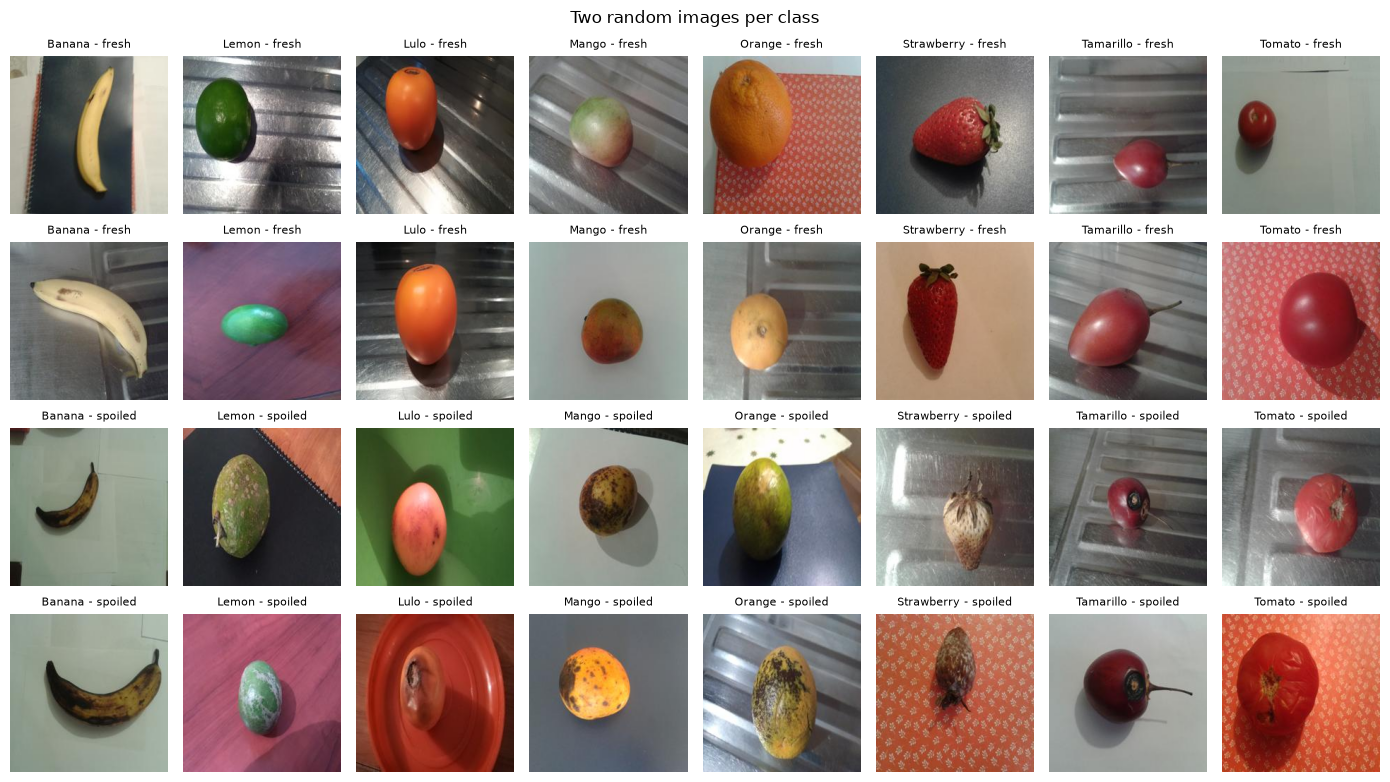

In [9]:
def show(ax, path, title):
    ax.imshow(Image.open(PROJECT_ROOT / path))
    ax.set_title(title, fontsize=8)
    ax.axis("off")


rng = np.random.default_rng(SEED)
kept_df = df[~df.excluded]
fig, axes = plt.subplots(4, len(FRUITS), figsize=(14, 8))
for col, fruit in enumerate(FRUITS):
    for i, state in enumerate(["fresh", "spoiled"]):
        pool = kept_df[(kept_df.fruit == fruit) & (kept_df.freshness == state)]
        for k, r in enumerate(pool.iloc[rng.choice(len(pool), 2, replace=False)].itertuples()):
            show(axes[2 * i + k, col], r.path, f"{fruit} - {state}")
fig.suptitle("Two random images per class")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "dataset_samples.png", dpi=150, bbox_inches="tight")

## 3. Near-duplicates and the grouped split

The photos were taken in bursts: the file number is the capture order and neighbouring files often show the same fruit from almost the same angle. If we split image by image at random, nearly identical frames end up in train and in test, and the test accuracy would be too optimistic.

So related images are grouped first and whole groups are put into one split:

1. every block of 25 consecutive files of a folder is one group;
2. two images of the same class are near-duplicates if their pHash distance is at most 6 and their thumbnails are almost equal, or if they are at most 50 files apart; groups connected by such a pair are merged (union-find);
3. inside each of the 16 classes (stratified), the groups are assigned from the largest to the smallest, each to the split that is furthest below its target of 70 / 15 / 15 %.

Examples of what the grouping has to catch:

pHash distance between neighbouring burst frames: [4, 6, 4]


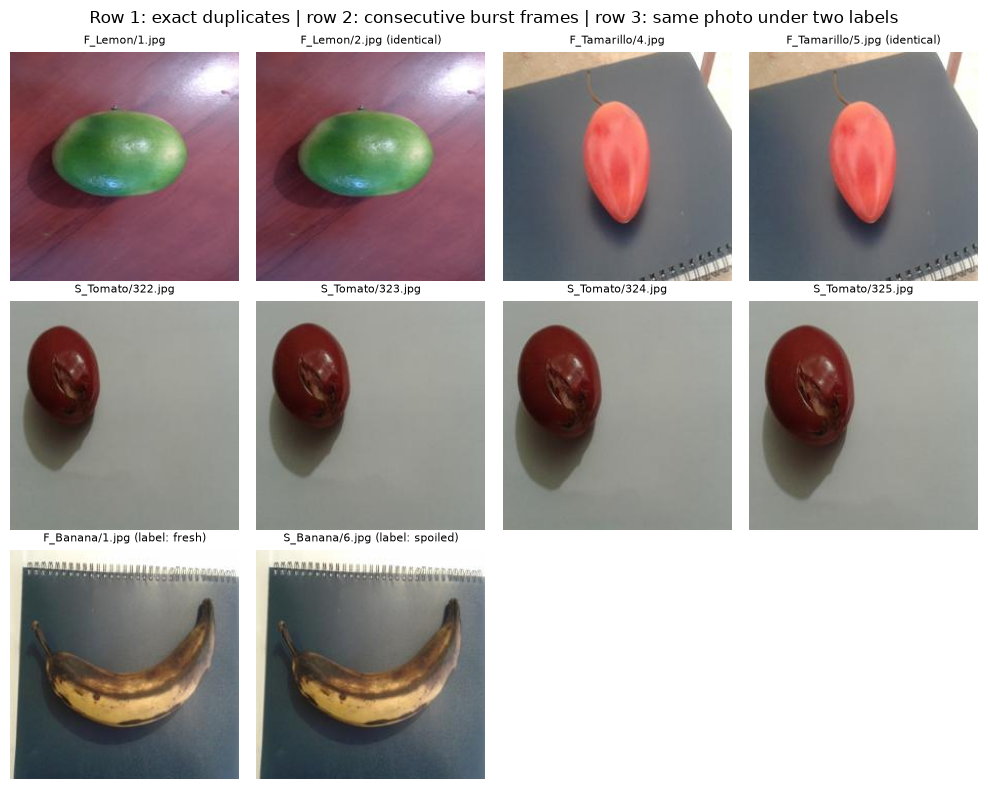

In [10]:
by_path = df.set_index("path")
kept = df[~df.excluded].reset_index()
kthumbs = thumbs[kept["index"].to_numpy()]

exact = []
for folder in ["F_Lemon", "F_Tamarillo"]:
    g = groups[groups.folder == folder].iloc[0]
    exact.append((g.kept, g.removed.split(";")[0]))
close = da.near_duplicate_pairs(kept, kthumbs, NEAR_DUP_PHASH, NEAR_DUP_THUMB)
linked = {(int(a), int(b)) for a, b in close}
starts = [i for i in range(len(kept) - 3)
          if kept.folder.iat[i] == kept.folder.iat[i + 3] and kept.folder.iat[i].startswith("S_")
          and all((i + k, i + k + 1) in linked for k in range(3))]
burst = kept.iloc[starts[len(starts) // 2]:][:4]

ph = da.phash_array(burst)
print("pHash distance between neighbouring burst frames:", [int(np.bitwise_count(ph[k] ^ ph[k - 1])) for k in range(1, 4)])

c = conflicts.iloc[0]
fig, axes = plt.subplots(3, 4, figsize=(10, 8))
for ax in axes.ravel():
    ax.axis("off")
for k, (a, b) in enumerate(exact):
    show(axes[0, 2 * k], a, a.split("FRUIT-16K/")[1])
    show(axes[0, 2 * k + 1], b, b.split("FRUIT-16K/")[1] + " (identical)")
for k, r in enumerate(burst.itertuples()):
    show(axes[1, k], r.path, f"{r.folder}/{r.file_index}.jpg")
for k, path in enumerate([c.path_a, c.path_b]):
    show(axes[2, k], path, path.split("FRUIT-16K/")[1] + f" (label: {by_path.loc[path, 'freshness']})")
fig.suptitle("Row 1: exact duplicates | row 2: consecutive burst frames | row 3: same photo under two labels")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "duplicate_examples.png", dpi=150, bbox_inches="tight")

In [11]:
# gom các ảnh gần trùng thành nhóm, rồi chia nguyên nhóm vào train/val/test để tránh rò rỉ dữ liệu
pairs = da.near_duplicate_pairs(kept, kthumbs, NEAR_DUP_PHASH, NEAR_DUP_THUMB, NEAR_DUP_GAP)
kept["group_id"] = da.build_groups(kept, pairs, BLOCK_SIZE)
kept["split"] = da.grouped_stratified_split(kept, SPLIT_RATIOS, SEED)

sizes = kept.groupby("group_id").size()
per_class = kept.groupby("combined_label")["group_id"].nunique()
largest = kept.groupby(["combined_label", "group_id"]).size().groupby("combined_label").max() / kept.groupby("combined_label").size()
print(f"near-duplicate pairs inside classes: {len(pairs)}")
print(f"groups: {len(sizes)} | per class min/median/max: {per_class.min()}/{int(per_class.median())}/{per_class.max()}")
print(f"group size min/median/max: {sizes.min()}/{int(sizes.median())}/{sizes.max()}")
print(f"largest group as share of its class: {largest.max():.1%} ({COMBINED_NAMES[int(largest.idxmax())]})")

near-duplicate pairs inside classes: 1026
groups: 492 | per class min/median/max: 20/30/39
group size min/median/max: 13/25/323
largest group as share of its class: 34.7% (Tomato_spoiled)


Save the split. `data/metadata.csv` has one row per original file (also the removed ones and why), `data/splits/<split>.csv` the images of each split.

In [12]:
METADATA_COLUMNS = ["path", "folder", "fruit", "freshness", "fruit_label", "freshness_label", "combined_label",
                    "combined_name", "file_index", "width", "height", "mode", "file_bytes", "sha256", "phash",
                    "is_exact_duplicate", "duplicate_of", "excluded", "exclude_reason", "group_id", "split"]
SPLIT_COLUMNS = ["path", "fruit", "freshness", "fruit_label", "freshness_label", "combined_label", "combined_name", "group_id"]

df["combined_name"] = [COMBINED_NAMES[c] for c in df.combined_label]
kept["combined_name"] = [COMBINED_NAMES[c] for c in kept.combined_label]
df["group_id"], df["split"] = -1, "excluded"
df.loc[kept["index"], "group_id"] = kept["group_id"].to_numpy()
df.loc[kept["index"], "split"] = kept["split"].to_numpy()

SPLITS_DIR.mkdir(parents=True, exist_ok=True)
df[METADATA_COLUMNS].to_csv(METADATA_CSV, index=False)
for s in SPLITS:
    kept.loc[kept.split == s, SPLIT_COLUMNS].to_csv(SPLITS_DIR / f"{s}.csv", index=False)
kept.split.value_counts()[SPLITS].to_frame("images").assign(share=lambda t: (t.images / t.images.sum()).round(3))

,images,share
split,,
train,10320,0.701
val,2203,0.150
test,2203,0.150


### Class distribution

In [13]:
rows = []
for label, name in enumerate(COMBINED_NAMES):
    raw, k = df[df.combined_label == label], kept[kept.combined_label == label]
    rows.append({"combined_label": label, "class": name, "folder": raw.folder.iat[0], "raw": len(raw),
                 "removed": int(raw.excluded.sum()), "clean": len(k), **{s: int((k.split == s).sum()) for s in SPLITS}})
dist = pd.DataFrame(rows)
total = dist[["raw", "removed", "clean", *SPLITS]].sum()
dist = pd.concat([dist, pd.DataFrame([{"combined_label": "", "class": "TOTAL", "folder": "", **total}])], ignore_index=True)
for s in SPLITS:
    dist[f"{s}_pct"] = (100 * dist[s] / dist["clean"]).round(1)
dist.to_csv(REPORTS_DIR / "class_distribution.csv", index=False)

body = dist[dist["class"] != "TOTAL"]
dev = max(abs(body[f"{s}_pct"] - 100 * SPLIT_RATIOS[s]).max() for s in SPLITS)
print(f"largest per-class deviation from 70/15/15: {dev:.1f} percentage points")
dist

largest per-class deviation from 70/15/15: 1.3 percentage points


,combined_label,class,folder,raw,removed,clean,train,val,test,train_pct,val_pct,test_pct
0,0,Banana_fresh,F_Banana,1000,1,999,699,150,150,70.0,15.0,15.0
1,1,Banana_spoiled,S_Banana,1000,0,1000,700,150,150,70.0,15.0,15.0
2,2,Lemon_fresh,F_Lemon,1000,445,555,391,82,82,70.5,14.8,14.8
3,3,Lemon_spoiled,S_Lemon,1000,0,1000,700,150,150,70.0,15.0,15.0
4,4,Lulo_fresh,F_Lulo,1000,442,558,394,82,82,70.6,14.7,14.7
5,5,Lulo_spoiled,S_Lulo,1000,0,1000,700,150,150,70.0,15.0,15.0
6,6,Mango_fresh,F_Mango,1000,0,1000,700,150,150,70.0,15.0,15.0
7,7,Mango_spoiled,S_Mango,1000,0,1000,700,150,150,70.0,15.0,15.0
8,8,Orange_fresh,F_Orange,1000,0,1000,700,150,150,70.0,15.0,15.0
9,9,Orange_spoiled,S_Orange,1000,0,1000,700,150,150,70.0,15.0,15.0


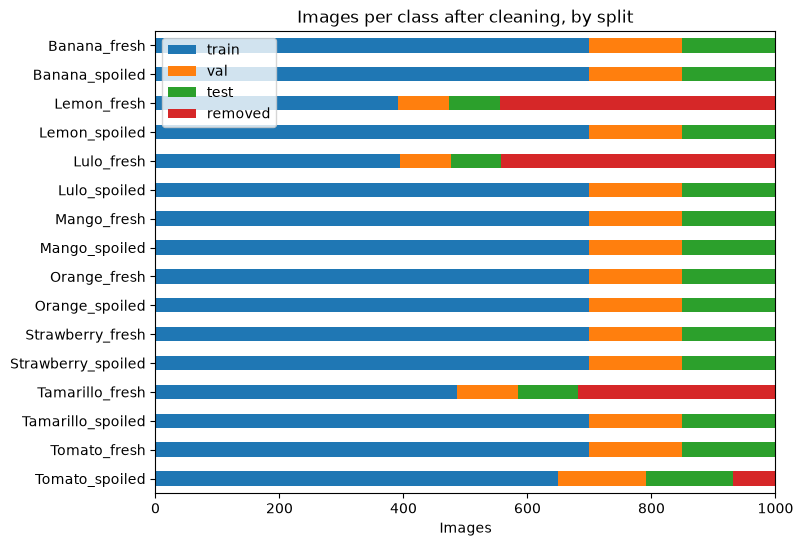

In [14]:
ax = body.set_index("class")[["train", "val", "test", "removed"]].iloc[::-1].plot.barh(stacked=True, figsize=(8, 6))
ax.set_xlabel("Images")
ax.set_ylabel("")
ax.set_title("Images per class after cleaning, by split")
plt.savefig(FIGURES_DIR / "class_distribution.png", dpi=150, bbox_inches="tight")

The classes are still balanced after cleaning (Lemon, Lulo and Tamarillo lost most copies), and every class is split close to 70 / 15 / 15.

## 4. Leakage check

For every validation and test image we look for the most similar training image of the same class. The same check is done for a plain random split (by image, stratified), only to compare.

In [15]:
# rò rỉ: ảnh val/test có bản gần giống trong tập train thì model chỉ cần "nhớ" là đoán đúng, kết quả test bị ảo
random_split = da.random_stratified_split(kept, SPLIT_RATIOS, SEED)
rows, matches = [], {}
for name, split in (("random split", random_split), ("grouped split", kept["split"].to_numpy())):
    for part in ("val", "test"):
        m = da.nearest_train_match(kept, kthumbs, split, part, NEAR_DUP_PHASH, NEAR_DUP_THUMB)
        matches[(name, part)] = m
        rows.append({"split_method": name, "evaluated_on": part, **da.leakage_summary(m, NEAR_DUP_PHASH, NEAR_DUP_THUMB)})
leak = pd.DataFrame(rows)
leak.to_csv(REPORTS_DIR / "leakage_comparison.csv", index=False)
leak.set_index(["split_method", "evaluated_on"]).T.round(3)

split_method                                     random split            \
evaluated_on                                              val      test   
n_images                                             2209.000  2209.000   
near-duplicate in train (pHash<=6 & thumb<=0.03)        0.059     0.065   
pHash<=6 match in train                                 0.100     0.097   
pHash<=10 match in train                                0.340     0.329   
thumb<=0.03 match in train                              0.263     0.260   
median nearest pHash distance                          12.000    12.000   

split_method                                     grouped split            
evaluated_on                                               val      test  
n_images                                              2203.000  2203.000  
near-duplicate in train (pHash<=6 & thumb<=0.03)         0.000     0.000  
pHash<=6 match in train                                  0.007     0.012  
pHash<=10 match in train                                 0.115     0.146  
thumb<=0.03 match in train                               0.085     0.057  
median nearest pHash distance                           16.000    14.000

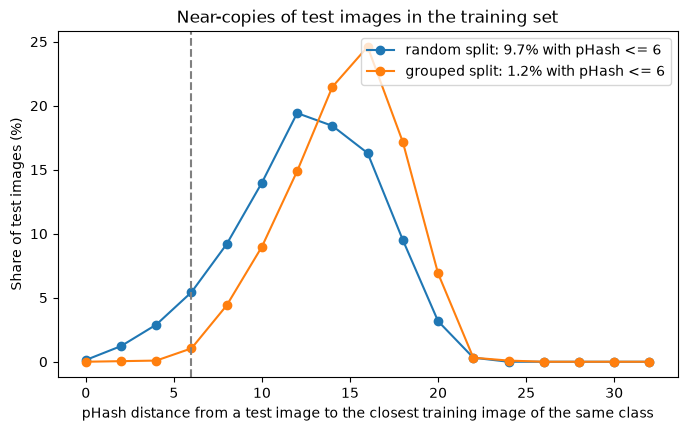

In [16]:
bins = np.arange(0, 33, 2)
fig, ax = plt.subplots(figsize=(8, 4.5))
for name in ("random split", "grouped split"):
    m = matches[(name, "test")]
    share = 100 * np.bincount(m["min_phash"].astype(int), minlength=33)[bins] / len(m)
    ax.plot(bins, share, marker="o", label=f"{name}: {(m['min_phash'] <= NEAR_DUP_PHASH).mean():.1%} with pHash <= {NEAR_DUP_PHASH}")
ax.axvline(NEAR_DUP_PHASH, color="gray", linestyle="--")
ax.set_xlabel("pHash distance from a test image to the closest training image of the same class")
ax.set_ylabel("Share of test images (%)")
ax.set_title("Near-copies of test images in the training set")
ax.legend()
fig.savefig(FIGURES_DIR / "split_leakage.png", dpi=150, bbox_inches="tight")

With a random split 6.5 % of the test images have a near-copy in the training set. With the grouped split there are none, and the closest training image is clearly further away (median pHash distance 14 to 16 instead of 12).

Final checks on the saved files (all must be 0):

In [17]:
splits = {s: pd.read_csv(SPLITS_DIR / f"{s}.csv") for s in SPLITS}
saved = pd.concat([d.assign(split=s) for s, d in splits.items()], ignore_index=True)
saved["sha256"] = by_path.loc[saved["path"], "sha256"].to_numpy()
split_of = dict(zip(saved["path"], saved["split"]))
checks = {
    "files in more than one split": int(saved["path"].duplicated().sum()),
    "clean files missing from the splits": len(set(kept["path"]) - set(saved["path"])),
    "removed files inside a split": int(saved["path"].isin(df.loc[df.excluded, "path"]).sum()),
    "identical files (SHA-256) in more than one split": int((saved.groupby("sha256")["split"].nunique() > 1).sum()),
    "groups in more than one split": int((saved.groupby("group_id")["split"].nunique() > 1).sum()),
    "near-duplicate pairs crossing splits": sum(split_of[kept.path.iat[a]] != split_of[kept.path.iat[b]] for a, b in pairs),
    "rows with combined != fruit * 2 + freshness": int((saved.combined_label != saved.fruit_label * 2 + saved.freshness_label).sum()),
}
assert not any(checks.values()), checks
checks

{'files in more than one split': 0,
 'clean files missing from the splits': 0,
 'removed files inside a split': 0,
 'identical files (SHA-256) in more than one split': 0,
 'groups in more than one split': 0,
 'near-duplicate pairs crossing splits': 0,
 'rows with combined != fruit * 2 + freshness': 0}

**Summary:** 16,000 files, 1,274 removed (1,273 exact copies and 1 mislabelled photo), 14,726 left. Grouped, stratified split: 10,320 train / 2,203 validation / 2,203 test images, with no near-copies across splits. All models use these split files.